In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

In [2]:
data = pd.DataFrame({

    'Weight': [
        150, 160, 170, 180, 140,
        110, 120, 130, 100, 125,
        200, 210, 220, 230, 205
    ],

    'Sweetness': [
        7, 8, 7, 9, 8,
        5, 6, 5, 4, 6,
        9, 8, 9, 10, 8
    ],

    'ColorScore': [
        8, 9, 8, 9, 7,
        4, 5, 4, 3, 5,
        9, 8, 10, 9, 8
    ],

    'Fruit': [
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Banana', 'Banana', 'Banana', 'Banana', 'Banana',
        'Mango', 'Mango', 'Mango', 'Mango', 'Mango'
    ]
})

data

,Weight,Sweetness,ColorScore,Fruit
0,150,7,8,Apple
1,160,8,9,Apple
2,170,7,8,Apple
3,180,9,9,Apple
4,140,8,7,Apple
5,110,5,4,Banana
6,120,6,5,Banana
7,130,5,4,Banana
8,100,4,3,Banana
9,125,6,5,Banana


In [4]:
X = data[
    ['Weight', 'Sweetness', 'ColorScore']
]

y = data['Fruit']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [6]:
model = RandomForestClassifier(
    n_estimators=10,
    criterion='entropy',
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=42)

In [7]:
y_pred = model.predict(
    X_test
)

print("Predictions:")
print(y_pred)

Predictions:
['Mango' 'Banana' 'Apple' 'Mango' 'Banana']


In [8]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 100.0 %


In [9]:
print(
    "Confusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Confusion Matrix:
[[1 0 0]
 [0 2 0]
 [0 0 2]]

Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         1
      Banana       1.00      1.00      1.00         2
       Mango       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [10]:
new_fruit = pd.DataFrame({
    'Weight': [165],
    'Sweetness': [8],
    'ColorScore': [8]
})

prediction = model.predict(
    new_fruit
)

print(
    "Final Predicted Fruit:",
    prediction[0]
)

Final Predicted Fruit: Apple


In [11]:
tree_predictions = []

for i, tree in enumerate(
    model.estimators_
):

    prediction = tree.predict(
        new_fruit
    )[0]

    tree_predictions.append(
        prediction
    )

    print(
        f"Tree {i+1}: {prediction}"
    )

Tree 1: 0.0
Tree 2: 0.0
Tree 3: 2.0
Tree 4: 0.0
Tree 5: 0.0
Tree 6: 0.0
Tree 7: 0.0
Tree 8: 0.0
Tree 9: 0.0
Tree 10: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: U

In [12]:
vote_counts = pd.Series(
    tree_predictions
).value_counts()

print(
    "Tree Voting:"
)

print(
    vote_counts
)

print(
    "\nFinal Class:",
    vote_counts.idxmax()
)

Tree Voting:
0.0    9
2.0    1
Name: count, dtype: int64

Final Class: 0.0


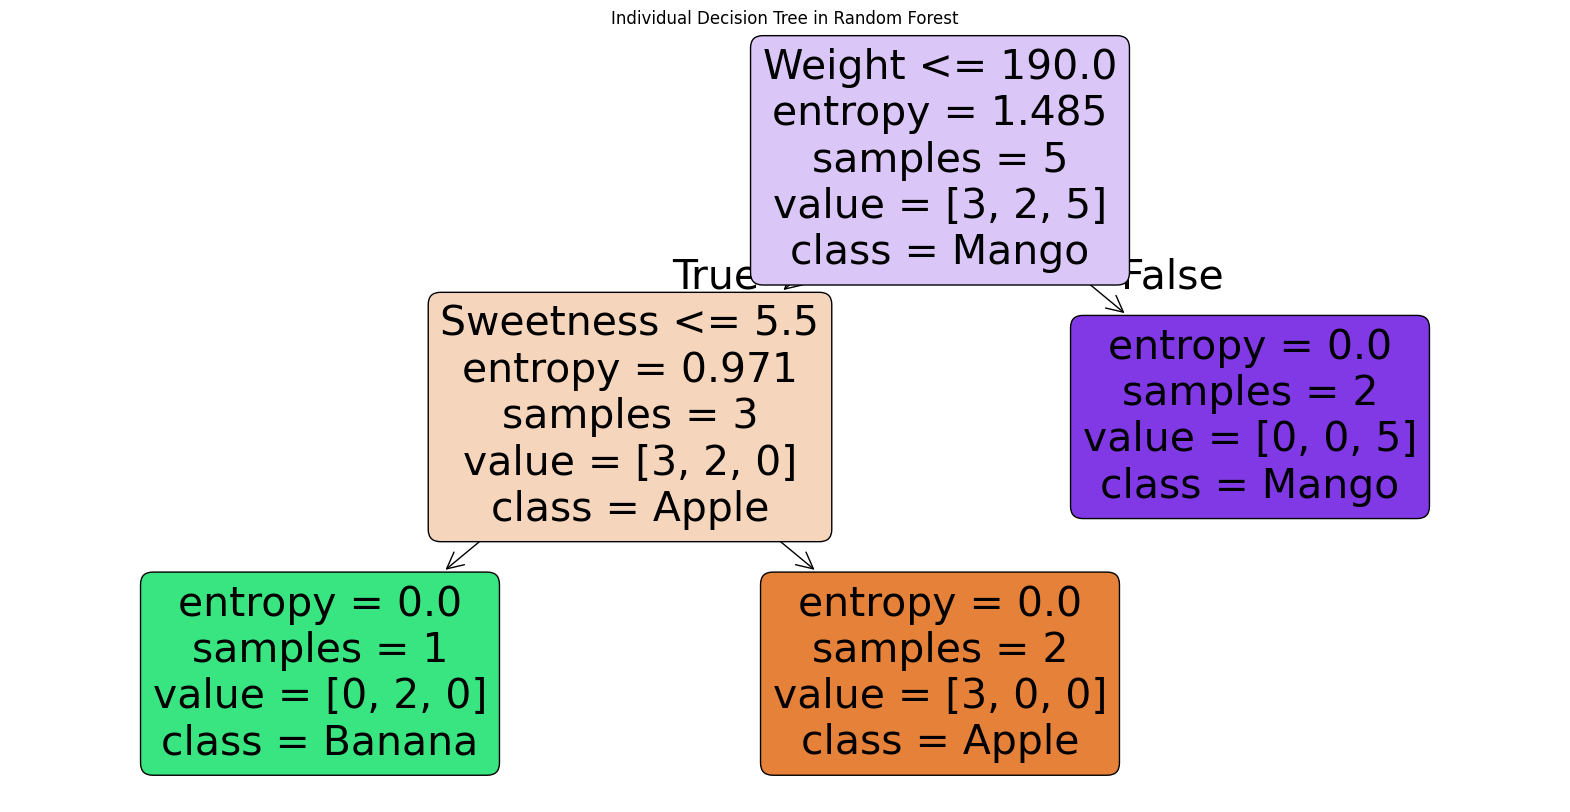

In [13]:
plt.figure(
    figsize=(20, 10)
)

plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.title(
    "Individual Decision Tree in Random Forest"
)

plt.show()